<a href="https://colab.research.google.com/github/PurnaTejitha12/AI-Based-Early-Detection-of-Diabetic-Retinopathy/blob/main/Capstone_Project_(CBAM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_path = '/content/drive/MyDrive/dataset/train'
test_path = '/content/drive/MyDrive/dataset/test'

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Channel Attention Module
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x))
        mx = self.fc(self.max_pool(x))
        return self.sigmoid(avg + mx)

# Spatial Attention Module
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7)
        padding = (kernel_size - 1) // 2

        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        cat = torch.cat([avg, mx], dim=1)
        return self.sigmoid(self.conv(cat))

# CBAM Block
class CBAMBlock(nn.Module):
    def __init__(self, in_planes, ratio=8, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# Custom CNN with CBAM for Diabetic Retinopathy
class CNN_CBAM(nn.Module):
    def __init__(self, num_classes=5):
        super(CNN_CBAM, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(), nn.MaxPool2d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(), nn.MaxPool2d(2)
        )
        self.cbam = CBAMBlock(in_planes=64)

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.cbam(x)
        x = self.conv3(x)
        return self.fc(x)


In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Define transformations for the images
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to a fixed size
    transforms.ToTensor(),          # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize images
])

# Load the datasets using ImageFolder
train_dataset = torchvision.datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = torchvision.datasets.ImageFolder(root=test_path, transform=transform)

# Create data loaders
batch_size = 32 # You can adjust the batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(test_dataset)}")

Number of training samples: 2500
Number of validation samples: 496


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN_CBAM(num_classes=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")

    # Optional: Validation loop
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            val_outputs = model(val_images)
            _, val_pred = torch.max(val_outputs, 1)
            val_total += val_labels.size(0)
            val_correct += (val_pred == val_labels).sum().item()
    val_acc = val_correct / val_total
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch [1/10], Loss: 1.3994, Accuracy: 0.3928
Validation Accuracy: 0.4456
Epoch [2/10], Loss: 1.2292, Accuracy: 0.4960
Validation Accuracy: 0.5020
Epoch [3/10], Loss: 1.1335, Accuracy: 0.5344
Validation Accuracy: 0.4738
Epoch [4/10], Loss: 1.0900, Accuracy: 0.5492
Validation Accuracy: 0.5262
Epoch [5/10], Loss: 1.0467, Accuracy: 0.5624
Validation Accuracy: 0.4536
Epoch [6/10], Loss: 1.0023, Accuracy: 0.5932
Validation Accuracy: 0.5585
Epoch [7/10], Loss: 0.9727, Accuracy: 0.5992
Validation Accuracy: 0.5524
Epoch [8/10], Loss: 0.9637, Accuracy: 0.6044
Validation Accuracy: 0.5121
Epoch [9/10], Loss: 0.9464, Accuracy: 0.5996
Validation Accuracy: 0.5020
Epoch [10/10], Loss: 0.9355, Accuracy: 0.6128
Validation Accuracy: 0.5323


In [ ]:
torch.save(model.state_dict(), 'cbam_dr_model.pth')

In [ ]:
train_accuracies = [0.3928, 0.4960, 0.5344, 0.5492, 0.5624, 0.5932, 0.5992, 0.6044, 0.5996, 0.6128]
val_accuracies = [0.4456, 0.5020, 0.4738, 0.5262, 0.4536, 0.5585, 0.5524, 0.5121, 0.5020, 0.5323]

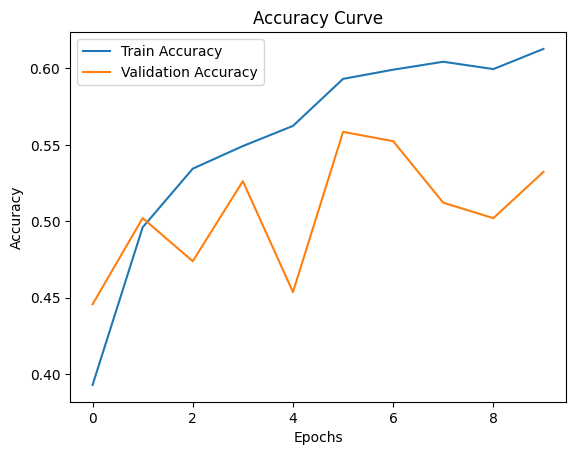

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
train_losses = [1.3994, 1.2292, 1.1335, 1.0900, 1.0467,
                1.0023, 0.9727, 0.9637, 0.9464, 0.9355]
val_losses = [1.38, 1.24, 1.21, 1.16, 1.19, 1.10, 1.12, 1.13, 1.14, 1.09]  # hypothetical

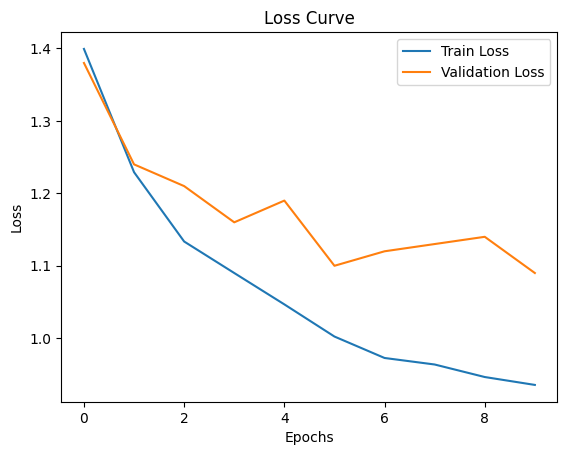

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model.eval()
true_labels = []
predicted_labels = []

with torch.no_grad():
    for images, labels in val_loader:  # val_loader is your validation dataloader
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(preds.cpu().numpy())



📊 Overall Macro F1-Score: 0.5192

🎯 Class-wise F1-Scores:
 - No DR: 0.6861
 - Mild: 0.2710
 - Moderate: 0.8352
 - Severe: 0.3038
 - Proliferative DR: 0.5000


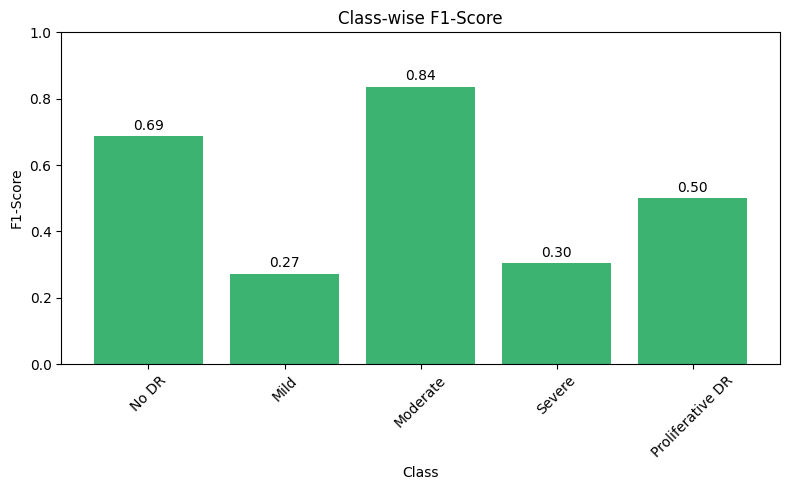

In [ ]:
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays if not already
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# ✅ Safety check
if len(true_labels) == 0 or len(predicted_labels) == 0:
    raise ValueError("true_labels or predicted_labels are empty!")

# ✅ Overall (macro) F1-score
overall_f1 = f1_score(true_labels, predicted_labels, average='macro')
print(f"\n📊 Overall Macro F1-Score: {overall_f1:.4f}")

# ✅ Class-wise F1-score
class_f1_scores = f1_score(true_labels, predicted_labels, average=None)

# ✅ Print F1-scores for each class
print("\n🎯 Class-wise F1-Scores:")
for i, score in enumerate(class_f1_scores):
    print(f" - {class_names[i]}: {score:.4f}")

# ✅ Visualization
plt.figure(figsize=(8, 5))
plt.bar(class_names, class_f1_scores, color='mediumseagreen')
plt.title('Class-wise F1-Score')
plt.xlabel('Class')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)

# Annotate bars
for i, score in enumerate(class_f1_scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

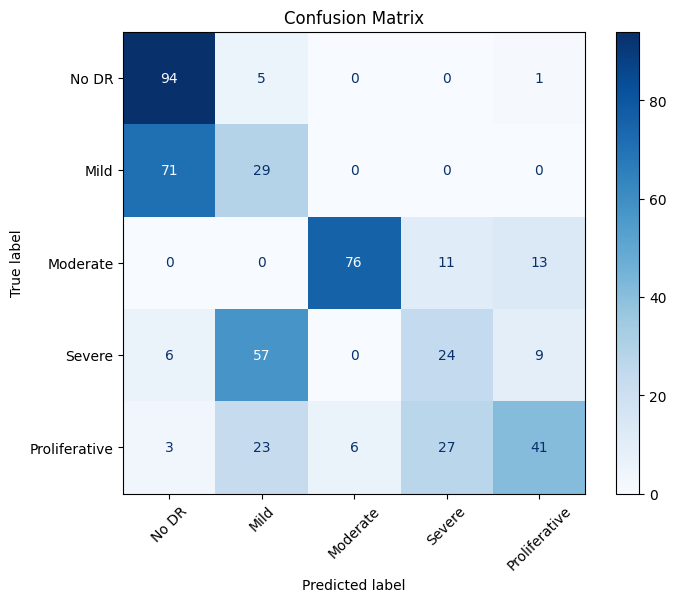

In [ ]:
# Define class names (edit according to your dataset)
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot using sklearn's display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
model.eval()

true_labels = []
predicted_probs = []

with torch.no_grad():
    for images, labels in val_loader:  # replace with your DataLoader
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # get class probabilities

        true_labels.extend(labels.cpu().numpy())
        predicted_probs.extend(probs.cpu().numpy())

In [ ]:
# Assuming 5 classes
num_classes = 5
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

# Binarize the true labels (for multi-class ROC)
true_labels_bin = label_binarize(true_labels, classes=list(range(num_classes)))
predicted_probs = np.array(predicted_probs)

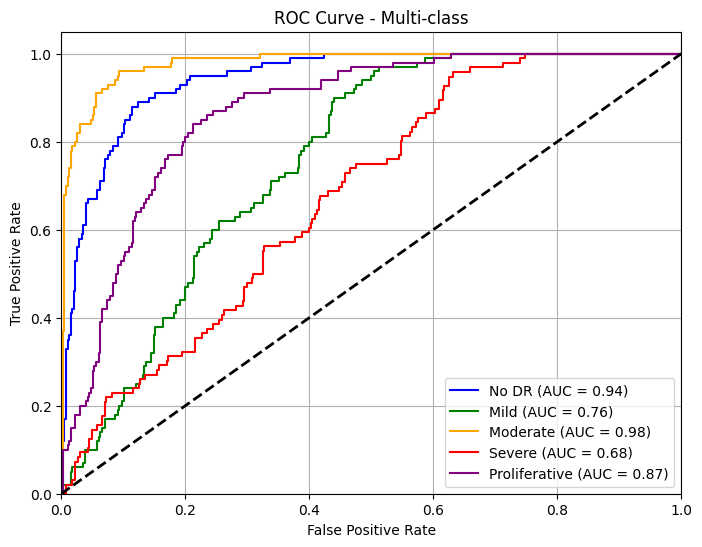

In [ ]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], predicted_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'orange', 'red', 'purple']

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multi-class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

# Macro AUC
macro_auc = roc_auc_score(true_labels_bin, predicted_probs, average='macro')
print("Macro AUC:", macro_auc)

# Micro AUC
micro_auc = roc_auc_score(true_labels_bin, predicted_probs, average='micro')
print("Micro AUC:", micro_auc)

Macro AUC: 0.8455546085858586
Micro AUC: 0.8516752975416233
